In [ ]:
import matplotlib.pylab as plt
import xarray as xr
import json

import sys
sys.path.append("../src")
import icon_grid_coarsening as igc

In [2]:
icon_grid = xr.open_dataset("grid.nc")
icon_grid['cell'] = icon_grid.cell.values
with open("../src/domains_indices.json", "r") as f:
    domains = json.load(f)
domain_cells = domains['domain03']
grid_sel = icon_grid.sel(cell=domain_cells)

In [3]:
factor = 32
assert factor % 4 == 0, "Factor must be a multiple of 4 for the coarsening to work properly."
subset_cells = grid_sel.isel(cell=slice(factor* 2 ** (2 * 4)))

In [4]:
# Create multi-level graph hierarchy
all_cells = subset_cells.cell.values

# Create coarsened levels (automatically generates multiple levels)
num_coarsening_levels = 4
coarsened_levels = igc.create_multilevel_hierarchy(
    all_cells, 
    icon_grid, 
    num_levels=num_coarsening_levels
)

# Create finest level with neighbor edges
finest_level = igc.create_finest_level(
    all_cells, 
    icon_grid, 
    subset_cells,
    triangles_for_neighbors=coarsened_levels[0]['triangles']
)

# Combine all levels (finest first, then coarsened levels)
all_levels = [finest_level] + coarsened_levels

# Print summary
print("Multi-level hierarchy created:\n")
for level in all_levels:
    print(f"{level['name']:25s} | "
          f"Nodes: {level['graph'].number_of_nodes():5d} | "
          f"Edges: {level['graph'].number_of_edges():5d}")

# Also create individual variables for backward compatibility (optional)
Gorg, orig_pos = finest_level['graph'], finest_level['pos']
G, pos = coarsened_levels[0]['graph'], coarsened_levels[0]['pos']
if len(coarsened_levels) > 1:
    Gcoarser, pos_coarser = coarsened_levels[1]['graph'], coarsened_levels[1]['pos']
if len(coarsened_levels) > 2:
    Gcoarsest, pos_coarsest = coarsened_levels[2]['graph'], coarsened_levels[2]['pos']
if len(coarsened_levels) > 3:
    Gcoarsestx, pos_coarsestx = coarsened_levels[3]['graph'], coarsened_levels[3]['pos']

Multi-level hierarchy created:

Original (finest)         | Nodes:  8192 | Edges:  6144
Level 0 (1st coarsening)  | Nodes:  2048 | Edges:  1536
Level 1 (2nd coarsening)  | Nodes:   512 | Edges:   384
Level 2 (3rd coarsening)  | Nodes:   128 | Edges:    96
Level 3 (4th coarsening)  | Nodes:    32 | Edges:    24


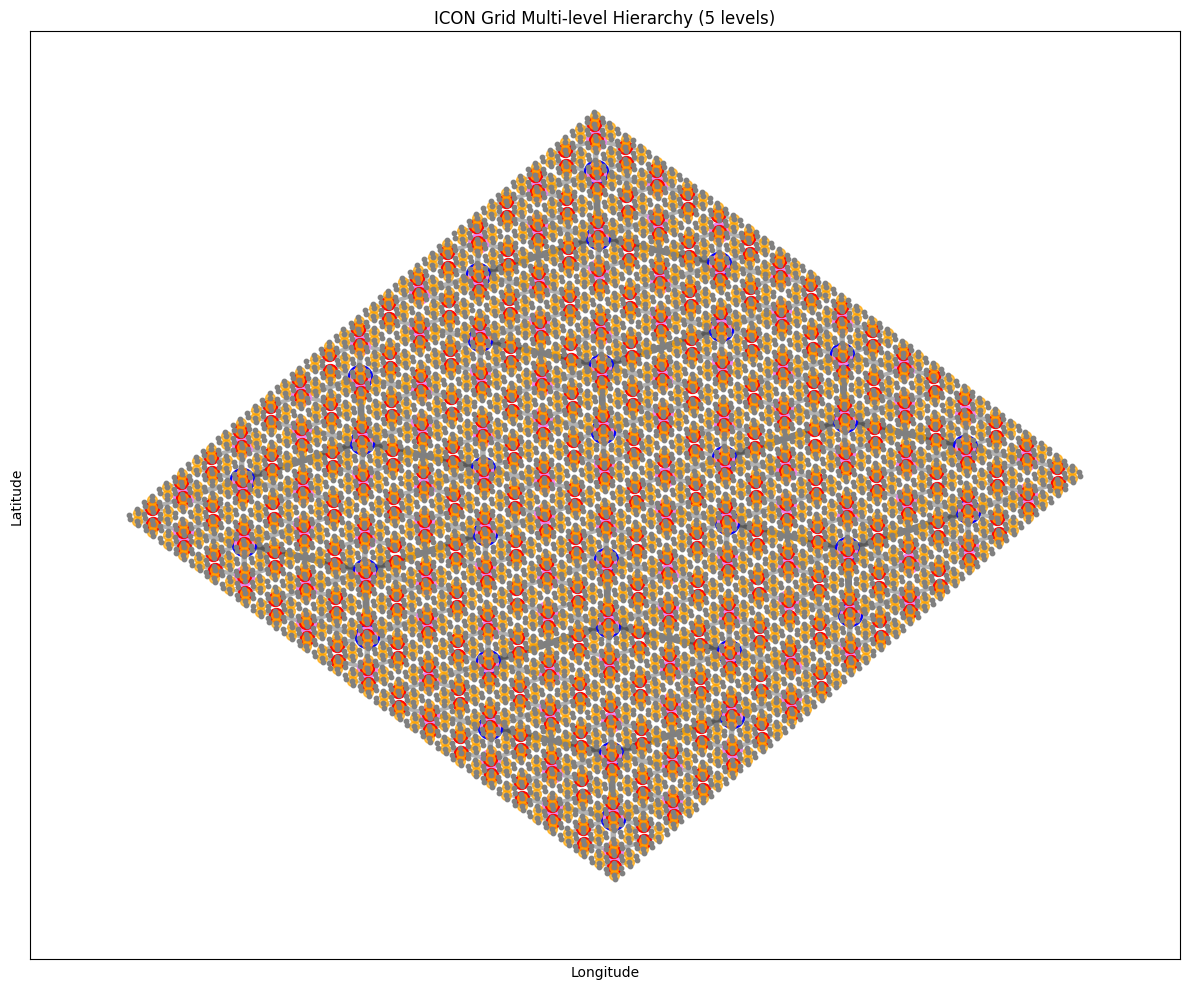

In [5]:
# Visualize all graph levels using the hierarchical data structure

# Define visualization properties for each level (coarsest to finest)
viz_properties = [
    {'node_size': 300, 'node_color': 'blue', 'edge_width': 5, 'edge_alpha': 0.5},      # Level 3
    {'node_size': 200, 'node_color': 'violet', 'edge_width': 4, 'edge_alpha': 0.3},    # Level 2
    {'node_size': 100, 'node_color': 'red', 'edge_width': 3, 'edge_alpha': 0.3},       # Level 1
    {'node_size': 50, 'node_color': 'orange', 'edge_width': 2, 'edge_alpha': 0.3, 'node_alpha': 0.7},  # Level 0
    {'node_size': 10, 'node_color': 'grey', 'edge_width': 0.5, 'edge_alpha': 0.3},     # Finest
]

# Build graphs_data from all_levels (reverse order to draw coarsest first)
graphs_data = []
for i, level in enumerate(reversed(all_levels)):
    props = viz_properties[i] if i < len(viz_properties) else {}
    graph_info = {
        'graph': level['graph'],
        'pos': level['pos'],
        **props  # Unpack visualization properties
    }
    graphs_data.append(graph_info)

fig, ax = igc.visualize_multilevel_graph(
    graphs_data,
    title=f'ICON Grid Multi-level Hierarchy ({len(all_levels)} levels)'
)
plt.show()

## Working with the Multi-Level Hierarchy

The `all_levels` list contains all graph levels from finest to coarsest. Each level is a dictionary with:
- `graph`: NetworkX Graph object
- `pos`: Position dictionary mapping cell IDs to (lon, lat)
- `cells`: Array of cell indices at this level
- `name`: Descriptive name
- `level`: Level index (-1 for finest, 0+ for coarsened levels)

You can easily:
- Access any level: `all_levels[i]`
- Iterate over levels: `for level in all_levels: ...`
- Extend to more levels by changing `num_coarsening_levels`
- Customize coarsening with `coarsening_configs` parameter

In [6]:
# Example: Access specific levels easily
print("Example usage of the hierarchical data structure:\n")

# Access finest level
print(f"Finest level has {all_levels[0]['graph'].number_of_nodes()} nodes")

# Access a specific coarsening level
print(f"Level 2 has {all_levels[3]['graph'].number_of_nodes()} nodes")

# Iterate and compute statistics
print("\nNode count reduction ratios:")
for i in range(len(all_levels) - 1):
    n1 = all_levels[i]['graph'].number_of_nodes()
    n2 = all_levels[i + 1]['graph'].number_of_nodes()
    ratio = n1 / n2 if n2 > 0 else 0
    print(f"  {all_levels[i]['name']} → {all_levels[i+1]['name']}: {ratio:.2f}x reduction")

Example usage of the hierarchical data structure:

Finest level has 8192 nodes
Level 2 has 128 nodes

Node count reduction ratios:
  Original (finest) → Level 0 (1st coarsening): 4.00x reduction
  Level 0 (1st coarsening) → Level 1 (2nd coarsening): 4.00x reduction
  Level 1 (2nd coarsening) → Level 2 (3rd coarsening): 4.00x reduction
  Level 2 (3rd coarsening) → Level 3 (4th coarsening): 4.00x reduction


In [8]:
# Example: Easily extend to more coarsening levels
# Just change num_coarsening_levels to create more levels automatically

# Create a hierarchy with 6 levels instead of 4
extended_levels = igc.create_multilevel_hierarchy(
    all_cells, 
    icon_grid, 
    num_levels=5  # Extend to 6 levels
)

extended_finest = igc.create_finest_level(
    all_cells, 
    icon_grid, 
    subset_cells,
    triangles_for_neighbors=extended_levels[0]['triangles']
)

all_extended_levels = [extended_finest] + extended_levels

print(f"Extended hierarchy with {len(all_extended_levels)} total levels:\n")
for level in all_extended_levels:
    print(f"{level['name']:30s} | Nodes: {level['graph'].number_of_nodes():5d}")

Extended hierarchy with 6 total levels:

Original (finest)              | Nodes:  8192
Level 0 (1st coarsening)       | Nodes:  2048
Level 1 (2nd coarsening)       | Nodes:   512
Level 2 (3rd coarsening)       | Nodes:   128
Level 3 (4th coarsening)       | Nodes:    32
Level 4 (5th coarsening)       | Nodes:     8
